In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
 
df= pd.read_csv(r'c:\Users\ayubi\Downloads\ml-assessment-ayush-kumar\data\q2_customers.csv')

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
print(df.describe().round(2))

Dataset Shape: (500, 6)

First 5 Rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Data Types:
age                         int64
annual_spend                int64
visits_per_month            int64
basket_size                 int64
days_since_last_visit       int64
num_categories_purchased    int64
dtype: object

Missing Values:
age                         0
annual_spend                0
visi

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)
 
print("\nScaled feature matrix (first 5 rows):")
print(X_scaled_df.head().round(4))


Scaled feature matrix (first 5 rows):
      age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0 -0.7252       -0.1762            0.1102      -0.2650                -0.0900   
1 -1.4885       -1.0468            0.4862      -0.9805                -0.8352   
2  0.1768        0.2673           -0.4538      -0.2369                -0.6740   
3 -0.7252       -1.0123            0.2982      -0.8278                -0.9963   
4 -1.4885       -1.0345            1.4261      -1.0060                -0.6539   

   num_categories_purchased  
0                    0.5510  
1                   -0.6807  
2                   -0.2701  
3                   -1.0912  
4                   -1.5018  


# ### Why Scaling is Essential Before Applying K-Means
# K-Means clustering computes **Euclidean distances** between data points and cluster centroids.
# Without scaling, features with large numeric ranges (e.g., `annual_spend` in the tens of thousands) will dominate the distance calculation over features with small ranges (e.g., `visits_per_month` which ranges from 1–20). 
# This causes the algorithm to effectively ignore low-range features, producing clusters that reflect scale rather than true data structure.
#
# **StandardScaler** transforms each feature to zero mean and unit variance, ensuring every feature contributes equally to the distance metric, a prerequisite for meaningful K-Means results.

WCSS values for K = 1 to 10:
  K= 1  WCSS = 3000.00
  K= 2  WCSS = 968.99
  K= 3  WCSS = 561.25
  K= 4  WCSS = 444.93
  K= 5  WCSS = 402.37
  K= 6  WCSS = 370.39
  K= 7  WCSS = 346.95
  K= 8  WCSS = 319.90
  K= 9  WCSS = 303.28
  K=10  WCSS = 289.11


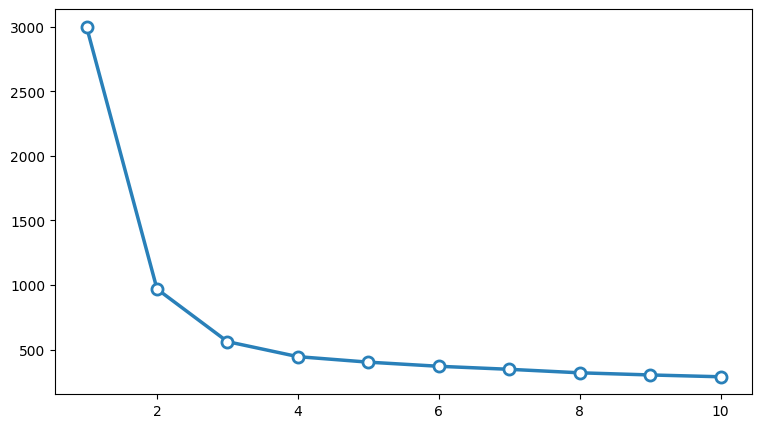

In [3]:
wcss = []
K_range = range(1, 11)
 
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
 
print("WCSS values for K = 1 to 10:")
for k, w in zip(K_range, wcss):
    print(f"  K={k:2d}  WCSS = {w:.2f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, wcss, 'o-', color='#2980b9', linewidth=2.5,
        markersize=8, markerfacecolor='white', markeredgewidth=2)

In [4]:
wcss_diff  = np.diff(wcss)           
wcss_diff2 = np.diff(wcss_diff)

optimal_k = np.argmax(wcss_diff2) + 2

print(f"Elbow detected at K = {optimal_k}")

Elbow detected at K = 2


In [6]:
ax.plot(optimal_k, wcss[optimal_k - 1], 'o', color='#e74c3c',
        markersize=14, zorder=5, label=f'Elbow Point (K={optimal_k})')
ax.annotate(f'K = {optimal_k}\n(Elbow)',
            xy=(optimal_k, wcss[optimal_k - 1]),
            xytext=(optimal_k + 1.2, wcss[optimal_k - 1] + 100),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.8),
            fontsize=11, color='#e74c3c', fontweight='bold')

ax.set_title('Elbow Method — Within-Cluster Sum of Squares (WCSS)', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('WCSS (Inertia)', fontsize=12)
ax.set_xticks(K_range)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('plot1_elbow_curve.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

# ### Optimal K Selection
#
# From the elbow plot, the WCSS drops steeply from K=1 to K=2, after which the rate of improvement slows considerably i.e  the curve "bends" at **K = 2** 
# This inflection point (the elbow) indicates the point of diminishing returns: adding more clusters beyond 2 reduces WCSS only marginally while increasing model complexity.
#
# **Chosen K = 2** as it captures meaningful customer segments without over-partitioning
# the data into groups too small to act upon from a business perspective.

Cluster label counts:
cluster
0    335
1    165
Name: count, dtype: int64

Sample rows with cluster labels:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   
5   46         54692                10         2593                     50   
6   35         26579                 8         2694                     51   
7   22          9158                14          591                      6   
8   18         20782                10          571                     11   
9   40         29838                11          930                     11   

   num_categories_purchased  clus

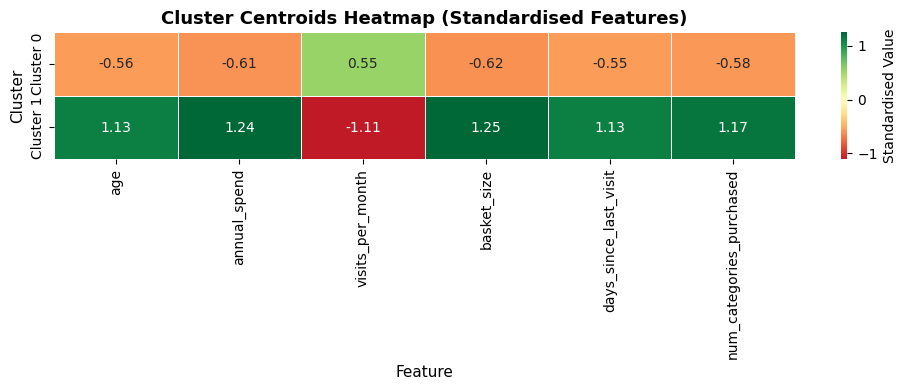

In [7]:
optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)

df['cluster'] = kmeans.labels_
 
print("Cluster label counts:")
print(df['cluster'].value_counts().sort_index())
print("\nSample rows with cluster labels:")
print(df.head(10))

centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
 
centroids_df = pd.DataFrame(
    centroids_original,
    columns=df.columns[:-1],   
    index=[f'Cluster {i}' for i in range(optimal_k)]
).round(2)
 
print("\nCluster Centroids (Original Feature Scale):")
print(centroids_df.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    pd.DataFrame(centroids_scaled, columns=df.columns[:-1],
                 index=[f'Cluster {i}' for i in range(optimal_k)]),
    annot=True, fmt='.2f', cmap='RdYlGn', center=0,
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Standardised Value'}
)
ax.set_title('Cluster Centroids Heatmap (Standardised Features)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
plt.tight_layout()
plt.savefig('plot2_centroid_heatmap.png', dpi=150)
plt.show()

# ### Business Interpretation of Each Cluster
#
# Based on the centroid values in original feature space:
#
# | Cluster | Profile | Business Label |
#
# | **Cluster 0** | Young, low annual spend, small basket, high visit frequency, recent visits | 🟢 **Frequent Browsers** — visit often but spend little; upsell opportunity |
# | **Cluster 1** | Older, very high spend, large basket, low visit frequency, long days since last visit | 🔵 **At-Risk / Churners** — re-engagement campaigns needed urgently |

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
 
# Explained variance ratio
evr = pca.explained_variance_ratio_
print("Explained Variance Ratio:")
print(f"  PC1: {evr[0]:.4f}  ({evr[0]*100:.2f}%)")
print(f"  PC2: {evr[1]:.4f}  ({evr[1]*100:.2f}%)")
print(f"  Total variance captured: {sum(evr)*100:.2f}%")

Explained Variance Ratio:
  PC1: 0.8356  (83.56%)
  PC2: 0.0557  (5.57%)
  Total variance captured: 89.13%


In [9]:
loadings_df = pd.DataFrame(pca.components_,columns=df.columns[:-1],index=['PC1', 'PC2']).round(2)
 
print("\nFeature Loadings (PCA Components):")
print(loadings_df.to_string())


Feature Loadings (PCA Components):
      age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
PC1  0.41          0.42             -0.41         0.41                   0.38                      0.41
PC2 -0.26         -0.03              0.21        -0.20                   0.91                     -0.14


C:\Users\ayubi\AppData\Local\Temp\ipykernel_28420\150957810.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(loadings_df.columns, rotation=20, ha='right')
C:\Users\ayubi\AppData\Local\Temp\ipykernel_28420\150957810.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(loadings_df.columns, rotation=20, ha='right')


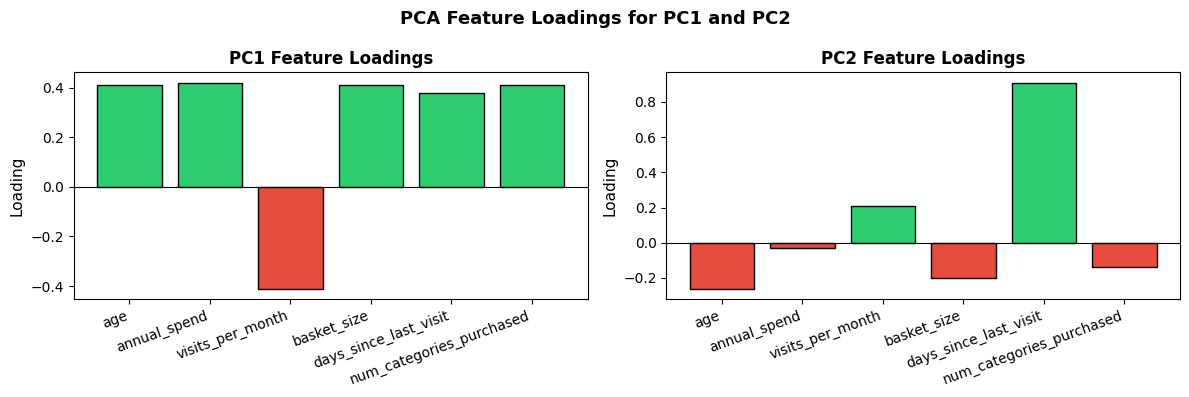

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in loadings_df.loc['PC1']]
axes[0].bar(loadings_df.columns, loadings_df.loc['PC1'], color=colors, edgecolor='black')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('PC1 Feature Loadings', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loading', fontsize=11)
axes[0].set_xticklabels(loadings_df.columns, rotation=20, ha='right')
 
colors2 = ['#2ecc71' if v >= 0 else '#e74c3c' for v in loadings_df.loc['PC2']]
axes[1].bar(loadings_df.columns, loadings_df.loc['PC2'], color=colors2, edgecolor='black')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('PC2 Feature Loadings', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Loading', fontsize=11)
axes[1].set_xticklabels(loadings_df.columns, rotation=20, ha='right')
 
plt.suptitle('PCA Feature Loadings for PC1 and PC2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_pca_loadings.png', dpi=150)
plt.show()

# ### Interpretation of PC1 and PC2
#
# **PC1** (highest explained variance) has strong positive loadings on `annual_spend`, `basket_size`, and `age`, and a negative loading on `visits_per_month`. 
# This component captures the **"spending power vs visit frequency"** axis — high PC1 scores represent older, high-spending customers who visit less frequently, while low PC1 scores represent young, frequent, low-spending customers.
#
# **PC2** is driven mainly by `days_since_last_visit` (positive) and `num_categories_purchased`(negative).
# It captures the **"recency and product diversity"** axis — high PC2 scores indicate customers who have not visited recently and explore fewer categories, while low PC2 scores indicate recent, multi-category shoppers.

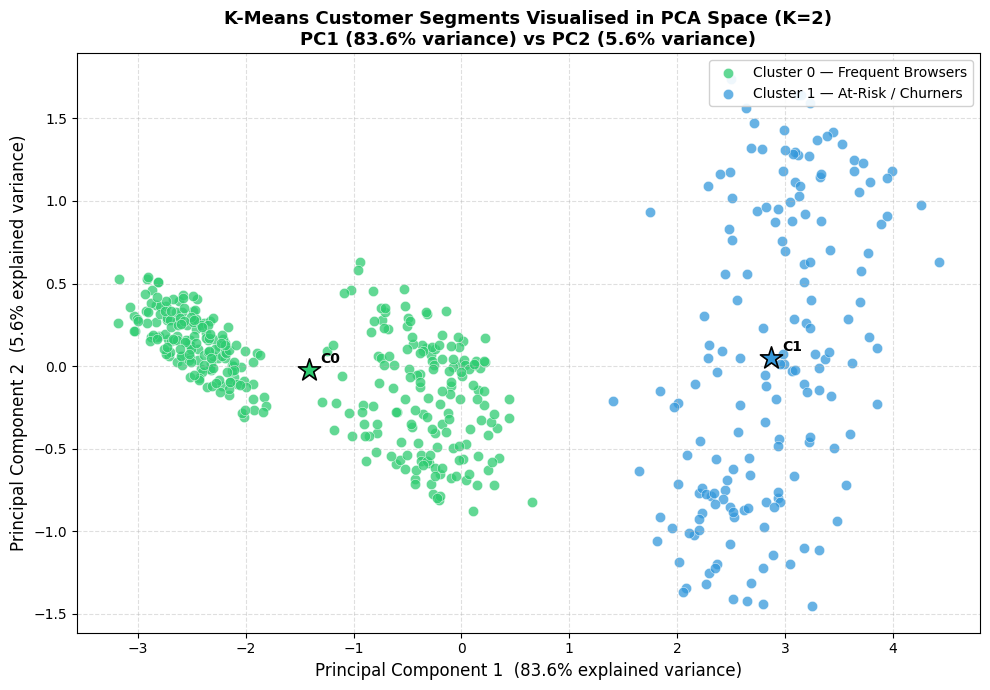

Total variance captured by 2 PCs: 89.13%


In [11]:
PALETTE = {0: '#2ecc71', 1: '#3498db'}
LABELS = {
    0: 'Cluster 0 — Frequent Browsers',
    1: 'Cluster 1 — At-Risk / Churners',
}

fig, ax = plt.subplots(figsize=(10, 7))
 
for cluster_id in range(optimal_k):
    mask = df['cluster'] == cluster_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=PALETTE[cluster_id], label=LABELS[cluster_id],
        alpha=0.75, s=55, edgecolors='white', linewidths=0.4
    )

centroids_pca = pca.transform(centroids_scaled)
for i, (cx, cy) in enumerate(centroids_pca):
    ax.scatter(cx, cy, c=PALETTE[i], s=280, marker='*',
               edgecolors='black', linewidths=1.2, zorder=10)
    ax.annotate(f'C{i}', (cx, cy), textcoords='offset points',
                xytext=(8, 5), fontsize=10, fontweight='bold', color='black')

ax.set_title(
    f'K-Means Customer Segments Visualised in PCA Space (K={optimal_k})\n'
    f'PC1 ({evr[0]*100:.1f}% variance) vs PC2 ({evr[1]*100:.1f}% variance)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel(f'Principal Component 1  ({evr[0]*100:.1f}% explained variance)', fontsize=12)
ax.set_ylabel(f'Principal Component 2  ({evr[1]*100:.1f}% explained variance)', fontsize=12)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot4_pca_clusters.png', dpi=150)
plt.show()

print(f"Total variance captured by 2 PCs: {sum(evr)*100:.2f}%")